# FFS / IFS Simulation Dashboard
**Forward Flux Sampling · IFS Weather Model**

Handles two data formats automatically:
- **FFS format**: `ic_time`, `flux_rate_per_day`, `lambda0_P_forward`, `ffs_speedup`, ...
- **IFS format**: `init_time`, `prob_lambda0`, `rate_lambda0_per_day`, `n_reached_B`, ...

## 1. Load Data

Point these to your TSV files. Format is auto-detected from column names.

In [1]:
import pandas as pd

In [ ]:
FFS_FILE = "/glade/derecho/scratch/schreck/FFS/results_mar18/ffs_statistics_all_ics.csv"
IFS_FILE = "/glade/derecho/scratch/schreck/FFS/results_mar18/IFS/ifs_rates_FFS.csv"

df_ffs = pd.read_csv(FFS_FILE)
df_ifs = pd.read_csv(IFS_FILE)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_flux_vs_lambda1_comparison(df_ffs, df_ifs, figsize=(14, 5)):
    """
    Compare flux rates and lambda1 transition probabilities between FFS and IFS methods.
    """
    # Convert to datetime if needed
    df_ffs = df_ffs.copy()
    df_ifs = df_ifs.copy()
    df_ffs['ic_time'] = pd.to_datetime(df_ffs['ic_time'])
    df_ifs['init_time'] = pd.to_datetime(df_ifs['init_time'])
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Flux Rate Comparison
    ax1 = axes[0]
    
    ax1.plot(df_ffs['ic_time'], df_ffs['flux_rate_per_day'], 'o-', 
             label='FFS', linewidth=2, markersize=8, alpha=0.7)
    ax1.plot(df_ifs['init_time'], df_ifs['rate_lambda0_flux_per_day'], 's-', 
             label='IFS', linewidth=2, markersize=8, alpha=0.7)
    
    ax1.set_xlabel('Initial Condition Time', fontsize=12)
    ax1.set_ylabel('Flux Rate (per day)', fontsize=12)
    ax1.set_title('Lambda0 Flux Rate Comparison', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Format x-axis dates
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Plot 2: Lambda1 Probability Comparison
    ax2 = axes[1]

    try:
        ax2.plot(df_ffs['ic_time'], df_ffs['lambda1_P_forward'], 'o-', 
                 label='FFS (P_forward)', linewidth=2, markersize=8, alpha=0.7)
        ax2.plot(df_ifs['init_time'], df_ifs['prob_lambda1'], 's-', 
                 label='IFS (prob)', linewidth=2, markersize=8, alpha=0.7)
        
        ax2.set_xlabel('Initial Condition Time', fontsize=12)
        ax2.set_ylabel('Probability', fontsize=12)
        ax2.set_title('Lambda1 Transition Probability', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(0, 1)
        
        # Format x-axis dates
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    except:
        pass
    
    plt.tight_layout()
    
    return fig, axes

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Lambda0 Flux Rate Comparison'}, xlabel='Initial Condition Time', ylabel='Flux Rate (per day)'>,
        <Axes: title={'center': 'Lambda1 Transition Probability'}, xlabel='Initial Condition Time', ylabel='Probability'>],
       dtype=object))

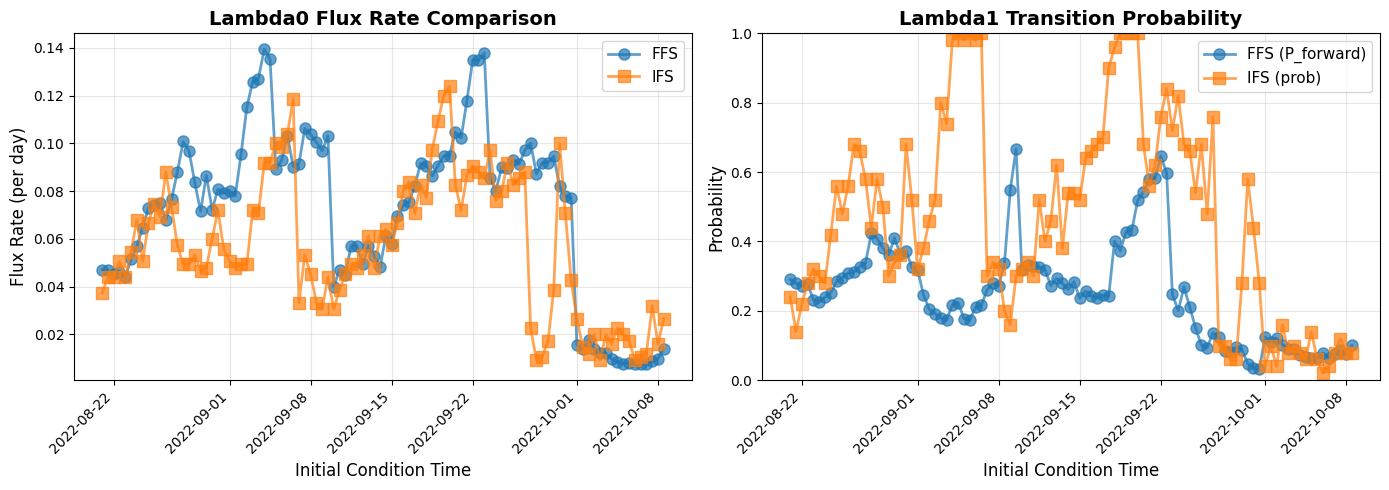

In [7]:
# plot_flux_vs_lambda1_comparison(pd.read_csv("results_feb11/ffs_statistics_all_ics.csv"), df_ifs)
plot_flux_vs_lambda1_comparison(df_ffs, df_ifs)

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import re

def plot_lambda_comparison(df_ffs, df_ifs, figsize=(16, 5)):
    """
    Automatically plots all shared lambda levels between FFS and IFS.
    Handles lambda0 (flux) separately.
    """

    df_ffs = df_ffs.copy()
    df_ifs = df_ifs.copy()

    df_ffs['ic_time'] = pd.to_datetime(df_ffs['ic_time'])
    df_ifs['init_time'] = pd.to_datetime(df_ifs['init_time'])

    # -----------------------
    # Detect available lambdas
    # -----------------------

    # Lambda0 (flux)
    has_lambda0 = (
        'flux_rate_per_day' in df_ffs.columns and
        'rate_lambda0_flux_per_day' in df_ifs.columns
    )

    # Detect lambda{i} automatically from FFS columns
    ffs_lambdas = [
        int(re.search(r'lambda(\d+)_P_forward', col).group(1))
        for col in df_ffs.columns
        if re.match(r'lambda\d+_P_forward', col)
    ]

    # Keep only lambdas that also exist in IFS
    shared_lambdas = [
        i for i in sorted(ffs_lambdas)
        if f'prob_lambda{i}' in df_ifs.columns
    ]

    n_plots = int(has_lambda0) + len(shared_lambdas)

    if n_plots == 0:
        raise ValueError("No shared lambda levels found.")

    import math

    # Compute grid shape
    ncols = min(3, n_plots)                  # max 3 per row looks clean
    nrows = math.ceil(n_plots / ncols)
    
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5*ncols, 4*nrows),
        squeeze=False
    )
    
    axes = axes.flatten()

    ax_idx = 0

    # -----------------------
    # Lambda0 (Flux)
    # -----------------------
    if has_lambda0:
        ax = axes[ax_idx]
        ax_idx += 1

        ax.plot(df_ffs['ic_time'], df_ffs['flux_rate_per_day'], 'o-',
                label='FFS', linewidth=2, markersize=7, alpha=0.8)

        ax.plot(df_ifs['init_time'], df_ifs['rate_lambda0_flux_per_day'], 's-',
                label='IFS', linewidth=2, markersize=7, alpha=0.8)

        ax.set_title('Lambda0 Flux Rate', fontweight='bold')
        ax.set_ylabel('Rate (per day)')
        ax.legend()
        ax.grid(True, alpha=0.3)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # -----------------------
    # Lambda1–N
    # -----------------------
    for i in shared_lambdas:
        ax = axes[ax_idx]
        ax_idx += 1

        ax.plot(df_ffs['ic_time'], df_ffs[f'lambda{i}_P_forward'], 'o-',
                label='FFS', linewidth=2, markersize=7, alpha=0.8)

        ax.plot(df_ifs['init_time'], df_ifs[f'prob_lambda{i}'], 's-',
                label='IFS', linewidth=2, markersize=7, alpha=0.8)

        ax.set_title(f'Lambda{i} Transition Probability', fontweight='bold')
        ax.set_ylabel('Probability')
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, alpha=0.3)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    return fig, axes

(<Figure size 1500x800 with 6 Axes>,
 array([<Axes: title={'center': 'Lambda0 Flux Rate'}, ylabel='Rate (per day)'>,
        <Axes: title={'center': 'Lambda1 Transition Probability'}, ylabel='Probability'>,
        <Axes: title={'center': 'Lambda2 Transition Probability'}, ylabel='Probability'>,
        <Axes: title={'center': 'Lambda3 Transition Probability'}, ylabel='Probability'>,
        <Axes: title={'center': 'Lambda4 Transition Probability'}, ylabel='Probability'>,
        <Axes: title={'center': 'Lambda5 Transition Probability'}, ylabel='Probability'>],
       dtype=object))

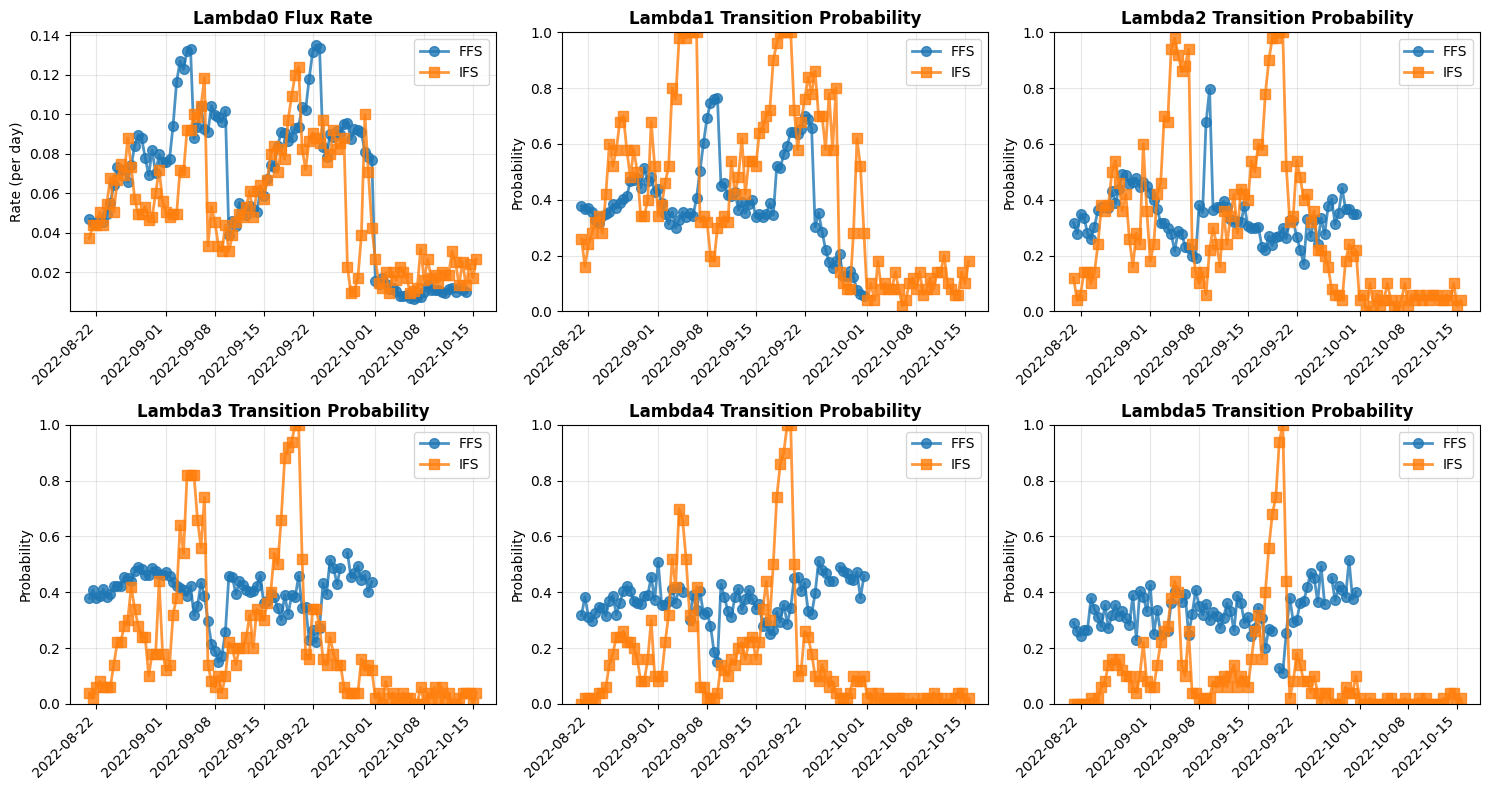

In [58]:
plot_lambda_comparison(df_ffs, df_ifs)

In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import re

def plot_all_rates_vs_time(df_ffs, df_ifs, figsize=(10, 5)):

    dfF = df_ffs.copy()
    dfI = df_ifs.copy()

    dfF["time"] = pd.to_datetime(dfF["ic_time"])
    dfI["time"] = pd.to_datetime(dfI["init_time"])

    # ---- Compute FFS λ0 ----
    dfF["lambda0_flux_rate_calc"] = (
        dfF["flux_lambda0_crossings"] /
        dfF["flux_total_time_days"]
    )

    # ---- Compute FFS full rate ----
    dfF["ffs_rate_calc"] = dfF["lambda0_flux_rate_calc"]
    for col in dfF.columns:
        if re.match(r"lambda\d+_P_forward", col):
            dfF["ffs_rate_calc"] *= dfF[col]

    # ---- Merge on time ----
    df = pd.merge(
        dfF[["time", "lambda0_flux_rate_calc", "ffs_rate_calc"]],
        dfI[["time", "rate_lambda0_flux_per_day", "rate_B_bf_per_day"]],
        on="time",
        how="outer"
    ).sort_values("time")

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(df["time"], df["lambda0_flux_rate_calc"],
            "o-", linewidth=2, markersize=8, label="FFS λ0")

    print(df["time"], df_ifs['rate_lambda0_flux_per_day'])
    ax.plot(df["time"], df_ifs['rate_lambda0_flux_per_day'], "D-", linewidth=2, markersize=8, label="IFS λ0")
    
    ax.plot(df["time"], df["ffs_rate_calc"],
            "s-", linewidth=2, markersize=8, label="FFS Full")

    ax.plot(df["time"], df["rate_B_bf_per_day"],
            "^-", linewidth=2, markersize=8, label="IFS Brute Force")

    ax.set_xlabel("Initial Condition Time")
    ax.set_ylabel("Rate (per day)")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    return fig, ax

0     2022-08-21 00:00:00
1     2022-08-21 12:00:00
2     2022-08-22 00:00:00
3     2022-08-22 12:00:00
4     2022-08-23 00:00:00
              ...        
107   2022-10-13 12:00:00
108   2022-10-14 00:00:00
109   2022-10-14 12:00:00
110   2022-10-15 00:00:00
111   2022-10-15 12:00:00
Name: time, Length: 112, dtype: datetime64[ns] 0      0.037333
1      0.044000
2      0.044000
3      0.050667
4      0.044000
         ...   
107    0.025333
108    0.013333
109    0.024000
110    0.017333
111    0.026667
Name: rate_lambda0_flux_per_day, Length: 112, dtype: float64


(<Figure size 1000x500 with 1 Axes>,
 <Axes: xlabel='Initial Condition Time', ylabel='Rate (per day)'>)

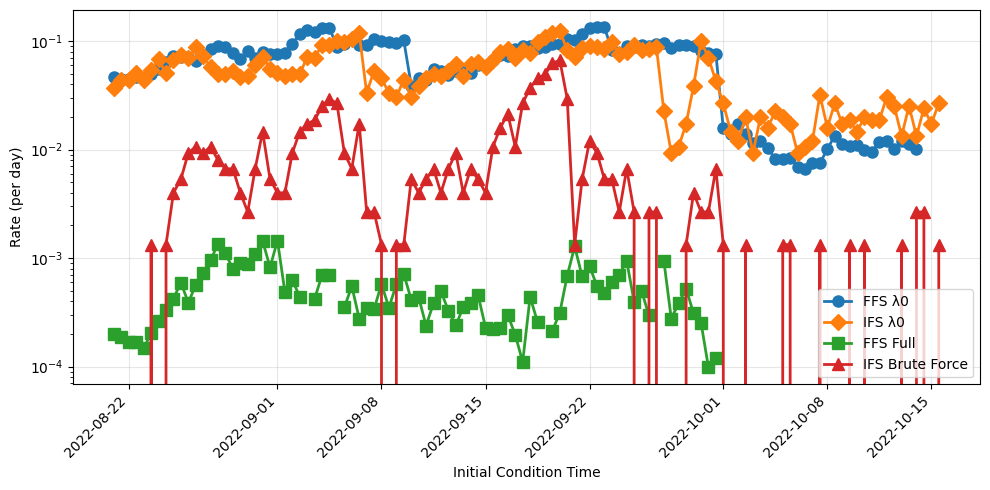

In [61]:
plot_all_rates_vs_time(df_ffs, df_ifs)

In [60]:
df_ifs.columns

Index(['init_time', 'n_members', 'n_starts_in_A', 'n_reached_B', 'n_B_from_A',
       'mean_time_to_B_hours', 'mean_time_to_B_days', 'n_lambda0_crossings',
       'n_cps_rejected', 'total_sim_days', 'rate_lambda0_flux_per_day',
       'rate_B_bf_per_day', 'prob_B', 'prob_B_from_A', 'n_crossed_lambda0',
       'rate_lambda0_per_day', 'prob_lambda0', 'n_crossed_lambda1',
       'rate_lambda1_per_day', 'prob_lambda1', 'n_crossed_lambda2',
       'rate_lambda2_per_day', 'prob_lambda2', 'n_crossed_lambda3',
       'rate_lambda3_per_day', 'prob_lambda3', 'n_crossed_lambda4',
       'rate_lambda4_per_day', 'prob_lambda4', 'n_crossed_lambda5',
       'rate_lambda5_per_day', 'prob_lambda5'],
      dtype='object')